# Quantitative Option Pricing and Volatility Analytics Suite

This notebook provides a comprehensive framework for understanding and applying various financial engineering models for option pricing and volatility analysis. It progresses from foundational models like Black-Scholes-Merton to more advanced stochastic volatility and jump-diffusion models, and includes tools for live market data integration, implied volatility calculation, and interactive visualization.

In [42]:
# ============================================================
# QUANTITATIVE OPTION PRICING & VOLATILITY ANALYTICS SUITE
# A Complete End-to-End Financial Engineering Notebook
# ============================================================
#
# Mathematical Progression:
#   1. Black-Scholes-Merton (1973) — Constant, continuous volatility; geometric
#      Brownian motion; log-normal terminal distribution.
#   2. Cox-Ross-Rubinstein Binomial Tree (1979) — Discrete-time lattice that
#      converges to BSM; naturally handles American early-exercise.
#   3. Merton Jump-Diffusion (1976) — Adds Poisson-distributed price jumps to
#      GBM, capturing fat tails and sudden crashes.
#   4. Heston Stochastic Volatility (1993) — CIR mean-reverting variance
#      process correlated with the asset, producing realistic vol smiles.
#
# Each layer relaxes one assumption of the prior model, culminating in a rich
# framework for real-world derivatives analytics.
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 1 · PROJECT OVERVIEW & DEPENDENCIES
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# Optional imports with graceful fallback for non-Colab environments
try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False
    print("yfinance not available — live market data features disabled.")

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("plotly not available — falling back to matplotlib for all plots.")

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available — interactive dashboard disabled.")

# Matplotlib global style
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "figure.dpi":       120,
})

ACCENT   = "#58a6ff"   # Blue accent
ACCENT2  = "#f78166"   # Orange-red accent
ACCENT3  = "#3fb950"   # Green accent
ACCENT4  = "#d2a8ff"   # Purple accent

print("✓ All dependencies loaded. Suite ready.")



✓ All dependencies loaded. Suite ready.


## CELL 1: Project Overview & Dependencies

This cell imports all necessary Python libraries for numerical computation, data handling, plotting, and financial modeling. It also includes graceful fallbacks for optional libraries like `yfinance` and `ipywidgets`, ensuring the notebook can still run in environments where these might not be available. Basic Matplotlib styling is applied for consistent visualization.

In [43]:

# ─────────────────────────────────────────────────────────────
# CELL 2 · LIVE MARKET DATA ENGINE
# ─────────────────────────────────────────────────────────────

class MarketDataEngine:
    """
    Pulls live market data via yfinance, computes historical volatility,
    and extracts option chains for downstream pricing and IV analysis.

    Parameters
    ----------
    ticker : str
        Equity ticker symbol, e.g. "SPY", "AAPL".
    period  : str
        Historical window for return computation (default "1y").
    """

    def __init__(self, ticker: str = "SPY", period: str = "1y"):
        self.ticker  = ticker.upper()
        self.period  = period
        self._stock  = None
        self._hist   = None

    # ── Internal helpers ──────────────────────────────────────

    def _ensure_loaded(self):
        """Lazy-load the yfinance Ticker and price history."""
        if self._stock is None:
            if not YFINANCE_AVAILABLE:
                raise RuntimeError("yfinance not installed.")
            self._stock = yf.Ticker(self.ticker)
            self._hist  = self._stock.history(period=self.period)
            if self._hist.empty:
                raise ValueError(f"No price history found for {self.ticker}.")

    # ── Public interface ───────────────────────────────────────

    def get_spot(self) -> float:
        """Return the most recent closing price."""
        self._ensure_loaded()
        return float(self._hist["Close"].iloc[-1])

    def get_risk_free_rate(self) -> float:
        """
        Approximate the annualised risk-free rate.

        Tries to fetch the 13-week Treasury bill yield (^IRX) from Yahoo.
        Falls back to a hard-coded 5.25 % if the feed is unavailable.
        The IRX quote is in percent, so divide by 100.
        """
        try:
            irx = yf.Ticker("^IRX").history(period="5d")
            if not irx.empty:
                return float(irx["Close"].iloc[-1]) / 100.0
        except Exception:
            pass
        return 0.0525   # sensible US-rate default (adjust as needed)

    def get_historical_vol(self, window: int = 21) -> float:
        """
        Annualised historical volatility from log returns.

        Uses a rolling standard deviation of daily log returns, then
        scales to annual frequency: σ_annual = σ_daily × √252.

        Parameters
        ----------
        window : int
            Rolling window in trading days (21 ≈ 1 month, 63 ≈ 3 months).
        """
        self._ensure_loaded()
        log_ret  = np.log(self._hist["Close"] / self._hist["Close"].shift(1)).dropna()
        vol_roll = log_ret.rolling(window).std() * np.sqrt(252)
        return float(vol_roll.iloc[-1])

    def get_vol_30d(self)  -> float: return self.get_historical_vol(21)
    def get_vol_90d(self)  -> float: return self.get_historical_vol(63)

    def get_option_chain(self, expiry_index: int = 1):
        """
        Fetch the option chain for a chosen expiry.

        Parameters
        ----------
        expiry_index : int
            Index into the sorted list of available expiries (0 = nearest).

        Returns
        -------
        calls, puts : pd.DataFrame
            Standard yfinance option chain DataFrames with columns including
            strike, lastPrice, bid, ask, impliedVolatility, volume, etc.
        expiry_str  : str
            The selected expiry date string.
        """
        self._ensure_loaded()
        expiries = self._stock.options
        if not expiries:
            raise ValueError(f"No options listed for {self.ticker}.")
        expiry_str = expiries[min(expiry_index, len(expiries) - 1)]
        chain      = self._stock.option_chain(expiry_str)
        return chain.calls, chain.puts, expiry_str

    def get_price_history(self) -> pd.Series:
        """Return the full Close price series."""
        self._ensure_loaded()
        return self._hist["Close"]


def demo_market_data(ticker="SPY"):
    """Quick smoke-test of the data engine."""
    if not YFINANCE_AVAILABLE:
        print("yfinance unavailable — skipping live data demo.")
        return
    eng = MarketDataEngine(ticker)
    S   = eng.get_spot()
    r   = eng.get_risk_free_rate()
    v30 = eng.get_vol_30d()
    v90 = eng.get_vol_90d()
    print(f"\n{'─'*45}")
    print(f"  Ticker  : {ticker}")
    print(f"  Spot    : ${S:,.2f}")
    print(f"  RF Rate : {r*100:.2f}%")
    print(f"  HVol 30d: {v30*100:.2f}%")
    print(f"  HVol 90d: {v90*100:.2f}%")
    print(f"{'─'*45}\n")

# Uncomment to run live:
# demo_market_data("AAPL")


## CELL 2: Live Market Data Engine

This section defines the `MarketDataEngine` class, which is responsible for fetching real-time financial data using the `yfinance` library. It can retrieve spot prices, historical volatility, risk-free rates (approximated from Treasury yields), and option chain data for a given ticker symbol. This engine is crucial for performing analyses with live market conditions.

In [44]:


# ─────────────────────────────────────────────────────────────
# CELL 3 · BASELINE PRICING ENGINES (CONSTANT VOLATILITY)
# ─────────────────────────────────────────────────────────────

# ════════════════════════════════════════
# 3A · Black-Scholes-Merton Engine
# ════════════════════════════════════════

class BlackScholes:
    """
    Analytical European option pricer under the Black-Scholes-Merton (1973)
    framework.

    Assumptions
    -----------
    · Underlying follows GBM: dS = μS dt + σS dW
    · σ is constant and known
    · Continuous dividend yield q (default 0)
    · Frictionless markets, continuous trading
    · Risk-free rate r is constant

    The celebrated BSM formula for a European call is:
        C = S·e^{-qT}·N(d1) - K·e^{-rT}·N(d2)
    where
        d1 = [ln(S/K) + (r - q + σ²/2)T] / (σ√T)
        d2 = d1 - σ√T

    Parameters
    ----------
    S : float  Spot price
    K : float  Strike price
    T : float  Time to expiry in years
    r : float  Annualised risk-free rate (continuously compounded)
    sigma : float  Annualised volatility
    q : float  Continuous dividend yield (default 0)
    """

    def __init__(self, S, K, T, r, sigma, q=0.0):
        # Guard against degenerate inputs
        self.S     = float(S)
        self.K     = float(K)
        self.T     = max(float(T), 1e-9)   # avoid division by zero at expiry
        self.r     = float(r)
        self.sigma = max(float(sigma), 1e-9)
        self.q     = float(q)
        self._d1, self._d2 = self._compute_d()

    def _compute_d(self):
        """
        Compute d1 and d2 — the standardised log-moneyness terms that appear
        in every BSM formula.  d1 is the risk-adjusted probability argument
        for the asset price, d2 for the cash strike.
        """
        sqT  = self.sigma * np.sqrt(self.T)
        d1   = (np.log(self.S / self.K) +
                (self.r - self.q + 0.5 * self.sigma**2) * self.T) / sqT
        d2   = d1 - sqT
        return d1, d2

    # ── Prices ────────────────────────────────────────────────

    def call(self) -> float:
        """European call price: C = S·e^{-qT}·N(d1) - K·e^{-rT}·N(d2)"""
        d1, d2 = self._d1, self._d2
        return (self.S * np.exp(-self.q * self.T) * norm.cdf(d1) -
                self.K * np.exp(-self.r * self.T) * norm.cdf(d2))

    def put(self) -> float:
        """European put price via put-call parity: P = C - S·e^{-qT} + K·e^{-rT}"""
        return (self.call() -
                self.S * np.exp(-self.q * self.T) +
                self.K * np.exp(-self.r * self.T))

    # ── Greeks ────────────────────────────────────────────────

    def delta(self, option_type="call") -> float:
        """
        Delta — first derivative of option price w.r.t. spot S.
        Economically: hedge ratio (units of underlying per option).
            Δ_call = e^{-qT}·N(d1)
            Δ_put  = -e^{-qT}·N(-d1) = e^{-qT}·(N(d1) - 1)
        """
        d_call = np.exp(-self.q * self.T) * norm.cdf(self._d1)
        if option_type.lower() == "call":
            return d_call
        return d_call - np.exp(-self.q * self.T)   # = e^{-qT}(N(d1)-1)

    def gamma(self) -> float:
        """
        Gamma — second derivative w.r.t. S; rate of change of delta.
        Same for calls and puts.
            Γ = e^{-qT}·n(d1) / (S·σ·√T)
        where n(·) is the standard normal PDF.
        """
        return (np.exp(-self.q * self.T) * norm.pdf(self._d1) /
                (self.S * self.sigma * np.sqrt(self.T)))

    def vega(self) -> float:
        """
        Vega — sensitivity to volatility σ (per 1-unit change, i.e. +100%).
        Divide by 100 for the conventional "per 1% move" quote.
            V = S·e^{-qT}·n(d1)·√T
        """
        return (self.S * np.exp(-self.q * self.T) *
                norm.pdf(self._d1) * np.sqrt(self.T))

    def theta(self, option_type="call") -> float:
        """
        Theta — time decay (per calendar day; divide annual by 365).
            Θ_call = -[S·e^{-qT}·n(d1)·σ/(2√T)]
                     - r·K·e^{-rT}·N(d2)
                     + q·S·e^{-qT}·N(d1)
        """
        S, K, T, r, sigma, q = (self.S, self.K, self.T,
                                 self.r, self.sigma, self.q)
        d1, d2 = self._d1, self._d2
        term1  = -(S * np.exp(-q*T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
        if option_type.lower() == "call":
            annual = term1 - r*K*np.exp(-r*T)*norm.cdf(d2) + q*S*np.exp(-q*T)*norm.cdf(d1)
        else:
            annual = term1 + r*K*np.exp(-r*T)*norm.cdf(-d2) - q*S*np.exp(-q*T)*norm.cdf(-d1)
        return annual / 365.0   # convert to per-calendar-day

    def rho(self, option_type="call") -> float:
        """
        Rho — sensitivity to risk-free rate r.
            ρ_call = K·T·e^{-rT}·N(d2)   (per 100% rate move)
        Divide by 100 for conventional "per 1 bp" quote.
        """
        K, T, r = self.K, self.T, self.r
        if option_type.lower() == "call":
            return K * T * np.exp(-r*T) * norm.cdf(self._d2)
        return -K * T * np.exp(-r*T) * norm.cdf(-self._d2)

    def all_greeks(self, option_type="call") -> dict:
        """Return a dictionary of all Greeks for the specified option type."""
        return {
            "Delta": self.delta(option_type),
            "Gamma": self.gamma(),
            "Vega" : self.vega() / 100,   # per 1% vol move (conventional)
            "Theta": self.theta(option_type),
            "Rho"  : self.rho(option_type) / 100,
        }


# ════════════════════════════════════════
# 3B · Vectorized Binomial Tree Engine (CRR)
# ════════════════════════════════════════

class BinomialCRR:
    """
    Cox-Ross-Rubinstein (1979) binomial lattice for European and American
    options.

    The CRR parameterisation ties the up/down multipliers to σ so that the
    discrete binomial distribution converges weakly to lognormal as N → ∞:
        u = exp(σ√Δt)
        d = 1/u = exp(-σ√Δt)
        p = (exp((r-q)Δt) - d) / (u - d)   [risk-neutral up probability]

    Implementation: backward induction using fully vectorised NumPy slicing.
    At each time slice k the option value vector has (k+1) elements; we
    back-propagate in O(N²) time but with near-zero Python overhead via
    array operations.

    Parameters
    ----------
    S     : float  Spot price
    K     : float  Strike price
    T     : float  Years to expiry
    r     : float  Risk-free rate
    sigma : float  Volatility
    q     : float  Continuous dividend yield
    N     : int    Number of time steps
    american : bool  Enable American early-exercise check
    """

    def __init__(self, S, K, T, r, sigma, q=0.0, N=200, american=False):
        self.S, self.K, self.T = float(S), float(K), max(float(T), 1e-9)
        self.r, self.sigma     = float(r), max(float(sigma), 1e-9)
        self.q                 = float(q)
        self.N                 = int(N)
        self.american          = bool(american)

    def _price(self, option_type: str) -> float:
        """
        Core backward-induction routine.

        Step 1: Build the terminal asset price array using the up/down
                multipliers.  Because of the recombining property the N+1
                terminal nodes can be computed in one vectorised expression:
                    S_T[j] = S · u^j · d^(N-j)   for j = 0, …, N

        Step 2: Compute terminal payoffs.

        Step 3: Discount backward through the tree.  At each interior node
                (time step k from expiry), the continuation value is:
                    C[i] = e^{-rΔt} · (p·V[i+1] + (1-p)·V[i])
                For American options we additionally compare with the
                intrinsic value and keep the maximum (early exercise).
        """
        N    = self.N
        dt   = self.T / N
        u    = np.exp(self.sigma * np.sqrt(dt))
        d    = 1.0 / u
        p    = (np.exp((self.r - self.q) * dt) - d) / (u - d)
        disc = np.exp(-self.r * dt)

        # Terminal asset prices — vectorised over j = 0..N
        j      = np.arange(0, N + 1)
        ST     = self.S * (u ** j) * (d ** (N - j))

        # Terminal payoffs
        if option_type.lower() == "call":
            V = np.maximum(ST - self.K, 0.0)
        else:
            V = np.maximum(self.K - ST, 0.0)

        # Backward induction — O(N) slicing operations each of decreasing length
        for k in range(N - 1, -1, -1):
            # Continuation value at each surviving node
            V     = disc * (p * V[1:k+2] + (1 - p) * V[0:k+1])
            # Early exercise check for American options
            if self.american:
                j_k   = np.arange(0, k + 1)
                S_k   = self.S * (u ** j_k) * (d ** (k - j_k))
                intrinsic = (np.maximum(S_k - self.K, 0.0)
                             if option_type.lower() == "call"
                             else np.maximum(self.K - S_k, 0.0))
                V = np.maximum(V, intrinsic)

        return float(V[0])

    def call(self) -> float:
        """Price a call option."""
        return self._price("call")

    def put(self) -> float:
        """Price a put option."""
        return self._price("put")


## CELL 3: Baseline Pricing Engines (Constant Volatility)

This cell implements two fundamental option pricing models:

### Black-Scholes-Merton (BSM) Engine

The `BlackScholes` class provides an analytical solution for pricing European options under a set of simplifying assumptions, including constant volatility. It also computes the standard option Greeks (Delta, Gamma, Vega, Theta, Rho), which measure the sensitivity of the option price to various parameters.

### Vectorized Binomial Tree (CRR) Engine

The `BinomialCRR` class implements the Cox-Ross-Rubinstein binomial tree model. This discrete-time model approximates the continuous BSM model and is particularly useful for pricing American options, as it inherently handles early exercise decisions through backward induction. The implementation is vectorized for efficiency.

In [45]:


# ─────────────────────────────────────────────────────────────
# CELL 4 · ADVANCED DIFFUSION & STOCHASTIC VOLATILITY ENGINES
# ─────────────────────────────────────────────────────────────

# ════════════════════════════════════════
# 4A · Merton Jump-Diffusion Engine (1976)
# ════════════════════════════════════════

class MertonJumpDiffusion:
    """
    Merton (1976) closed-form option pricer with Poisson-distributed jumps.

    Model:
        dS/S = (μ - λ·k̄) dt + σ dW + (J-1) dN

    where:
        σ     = continuous diffusion volatility
        λ     = Poisson intensity (expected jumps per year)
        J     = log-normal jump size, ln(J) ~ N(μ_j, σ_j²)
        k̄    = E[J-1] = exp(μ_j + σ_j²/2) - 1   (mean relative jump)
        dN    = Poisson increment

    The Merton formula is an infinite weighted sum of BSM prices, where
    the n-th term conditions on exactly n jumps occurring:

        C = Σ_{n=0}^{N} [e^{-λ'T}(λ'T)^n / n!] · BSM(S, K, T, r_n, σ_n)

    with:
        λ' = λ(1 + k̄)          (risk-neutral jump intensity)
        r_n = r - λ·k̄ + n·ln(1+k̄)/T   (adjusted drift for n-jump scenario)
        σ_n = sqrt(σ² + n·σ_j²/T)      (augmented vol for n-jump scenario)

    The series is truncated at N_terms (50 default); the tail is negligible
    for all practical λT values.

    Parameters
    ----------
    S, K, T, r, sigma : standard BSM parameters
    lam   : Poisson jump intensity λ (jumps/year)
    mu_j  : Mean of log-jump (ln J), typically negative for equity crash risk
    sig_j : Std dev of log-jump
    N_terms : Number of Poisson terms in the series (≥ 30 for accuracy)
    """

    def __init__(self, S, K, T, r, sigma,
                 lam=0.5, mu_j=-0.1, sig_j=0.2, N_terms=50):
        self.S, self.K, self.T = float(S), float(K), max(float(T), 1e-9)
        self.r, self.sigma     = float(r), max(float(sigma), 1e-9)
        self.lam               = float(lam)
        self.mu_j              = float(mu_j)
        self.sig_j             = float(sig_j)
        self.N_terms           = int(N_terms)

    def _price(self, option_type: str) -> float:
        S, K, T, r, sigma = self.S, self.K, self.T, self.r, self.sigma
        lam, mu_j, sig_j  = self.lam, self.mu_j, self.sig_j

        # Expected relative jump size
        k_bar  = np.exp(mu_j + 0.5 * sig_j**2) - 1.0
        # Risk-neutral jump intensity
        lam_p  = lam * (1.0 + k_bar)

        price  = 0.0
        ns     = np.arange(0, self.N_terms)

        # Poisson weights (in log space for numerical stability)
        log_wt = (ns * np.log(lam_p * T + 1e-300)
                  - lam_p * T
                  - [sum(np.log(np.arange(1, n+1))) if n>0 else 0 for n in ns])
        wt     = np.exp(log_wt)

        for n, w in zip(ns, wt):
            # Per-jump-count adjusted parameters
            r_n   = r - lam * k_bar + n * np.log(1.0 + k_bar) / T
            var_n = sigma**2 + n * sig_j**2 / T
            sig_n = max(np.sqrt(var_n), 1e-9)
            bsm   = BlackScholes(S, K, T, r_n, sig_n)
            price += w * (bsm.call() if option_type == "call" else bsm.put())

        return price

    def call(self) -> float: return self._price("call")
    def put(self)  -> float: return self._price("put")


# ════════════════════════════════════════
# 4B · Heston Stochastic Volatility (Monte Carlo)
# ════════════════════════════════════════

class HestonMonteCarlo:
    """
    Heston (1993) stochastic volatility model priced via Monte Carlo with
    Euler-Maruyama discretisation of the joint SDE system.

    Dynamics under the risk-neutral measure Q:
        dS  = r·S dt + √v · S dW₁
        dv  = κ(θ - v) dt + ξ·√v dW₂
        dW₁ dW₂ = ρ dt

    Parameters
    ----------
    S     : float  Spot price
    K     : float  Strike price
    T     : float  Time to expiry in years
    r     : float  Risk-free rate
    v0    : float  Initial variance (≈ σ₀²)
    kappa : float  Mean-reversion speed of variance
    theta : float  Long-run variance (ξ² steady-state)
    xi    : float  Vol-of-vol ξ (volatility of variance)
    rho   : float  Correlation between asset and variance Brownian motions
    n_paths : int  Number of Monte Carlo paths
    n_steps : int  Number of time discretisation steps
    seed    : int  RNG seed for reproducibility
    """

    def __init__(self, S, K, T, r,
                 v0=0.04, kappa=2.0, theta=0.04,
                 xi=0.3, rho=-0.7,
                 n_paths=20_000, n_steps=252, seed=42):
        self.S, self.K, self.T, self.r = (float(S), float(K),
                                           max(float(T), 1e-9), float(r))
        self.v0, self.kappa  = max(float(v0), 1e-9), float(kappa)
        self.theta, self.xi  = max(float(theta), 1e-9), float(xi)
        self.rho             = float(np.clip(rho, -0.9999, 0.9999))
        self.n_paths         = int(n_paths)
        self.n_steps         = int(n_steps)
        self.seed            = seed

    def simulate(self, return_paths=False):
        """
        Vectorised Euler-Maruyama simulation of n_paths correlated
        (S, v) trajectories.

        Variance boundary condition: Full Truncation (FT) scheme.
        The CIR process can go negative in Euler discretisation when ξ is
        large.  We apply v⁺ = max(v, 0) before taking the square root
        (absorption at zero), which is both simple and accurate.

        Correlated Brownian motions:
            W₁ and W₂ are independent N(0,1) shocks.
            Z₁ = W₁
            Z₂ = ρ·W₁ + √(1-ρ²)·W₂
        This Cholesky decomposition correctly produces Corr(Z₁,Z₂) = ρ.

        Returns
        -------
        S_paths : ndarray (n_steps+1, n_paths)  asset paths
        v_paths : ndarray (n_steps+1, n_paths)  variance paths
        """
        rng  = np.random.default_rng(self.seed)
        dt   = self.T / self.n_steps
        sqdt = np.sqrt(dt)
        rho2 = np.sqrt(max(1.0 - self.rho**2, 0.0))

        # Pre-allocate path matrices
        S_paths = np.zeros((self.n_steps + 1, self.n_paths))
        v_paths = np.zeros((self.n_steps + 1, self.n_paths))
        S_paths[0] = self.S
        v_paths[0] = self.v0

        S_cur = np.full(self.n_paths, self.S)
        v_cur = np.full(self.n_paths, self.v0)

        for t in range(self.n_steps):
            W1  = rng.standard_normal(self.n_paths)
            W2  = rng.standard_normal(self.n_paths)
            Z1  = W1
            Z2  = self.rho * W1 + rho2 * W2

            v_pos = np.maximum(v_cur, 0.0)   # FT truncation
            sv    = np.sqrt(v_pos)

            # Variance Euler step  (CIR)
            v_cur = (v_cur
                     + self.kappa * (self.theta - v_pos) * dt
                     + self.xi * sv * sqdt * Z2)

            # Asset log-price Euler step (Milstein equivalent for GBM)
            S_cur = S_cur * np.exp(
                (self.r - 0.5 * v_pos) * dt + sv * sqdt * Z1)

            S_paths[t+1] = S_cur
            v_paths[t+1] = v_cur

        if return_paths:
            return S_paths, v_paths
        return S_cur, v_cur   # only terminal states needed for pricing

    def _price(self, option_type: str) -> float:
        """
        Risk-neutral Monte Carlo pricing:
            C = e^{-rT} · E_Q[max(S_T - K, 0)]
        """
        S_T, _ = self.simulate()
        if option_type == "call":
            payoffs = np.maximum(S_T - self.K, 0.0)
        else:
            payoffs = np.maximum(self.K - S_T, 0.0)
        return float(np.exp(-self.r * self.T) * np.mean(payoffs))

    def call(self) -> float: return self._price("call")
    def put(self)  -> float: return self._price("put")

    def get_sample_paths(self, n_sample=10):
        """
        Return a small subset of paths for visualisation.

        Returns
        -------
        S_paths : (n_steps+1, n_sample)  price paths
        v_paths : (n_steps+1, n_sample)  variance paths
        """
        full_S, full_v = self.simulate(return_paths=True)
        idx = np.linspace(0, self.n_paths - 1, n_sample, dtype=int)
        return full_S[:, idx], full_v[:, idx]


## CELL 4: Advanced Diffusion & Stochastic Volatility Engines

This section introduces more sophisticated option pricing models that relax some of the restrictive assumptions of the BSM model:

### Merton Jump-Diffusion Engine (1976)

The `MertonJumpDiffusion` class incorporates sudden, discrete jumps into the asset price process, in addition to continuous diffusion. This model, priced as an infinite weighted sum of BSM prices, better captures phenomena like sudden market crashes and fat tails in return distributions, which are often observed in real-world markets.

### Heston Stochastic Volatility (Monte Carlo)

The `HestonMonteCarlo` class implements the Heston model, which allows for stochastic (randomly varying) volatility that mean-reverts over time. This model is often priced using Monte Carlo simulations due to the complexity of its underlying stochastic differential equations. It is capable of generating realistic volatility smiles and clusters, reflecting that volatility itself is not constant but evolves dynamically.

In [46]:

# ─────────────────────────────────────────────────────────────
# CELL 5 · IMPLIED VOLATILITY & NUMERICAL RISK ANALYTICS
# ─────────────────────────────────────────────────────────────

# ════════════════════════════════════════
# 5A · Implied Volatility Solver
# ════════════════════════════════════════

def implied_vol(market_price: float, S: float, K: float, T: float,
                r: float, option_type: str = "call",
                q: float = 0.0,
                tol: float = 1e-6,
                max_iter: int = 200,
                debug_print: bool = False) -> float:
    """
    Extract the Black-Scholes Implied Volatility from a market option price.

    Algorithm
    ---------
    1. Newton-Raphson (NR): fast quadratic convergence near the solution.
       Update rule:  σ_{n+1} = σ_n - [BSM(σ_n) - C_mkt] / Vega(σ_n)
       NR can fail if Vega ≈ 0 (deep ITM/OTM or very short expiry).
    2. Brent (scipy brentq): robust bracketed root-finding fallback.
       Bracket [1e-4, 10.0] covers all practical vol levels.

    Parameters
    ----------
    market_price : float  Observed option mid-price
    S, K, T, r   : standard parameters
    option_type  : "call" or "put"
    q            : dividend yield
    tol          : convergence tolerance
    max_iter     : max NR iterations before falling back
    debug_print  : bool  If True, print debug information when a solution is not found.

    Returns
    -------
    float  Implied volatility (annualised), or NaN if no solution found.
    """
    T = max(T, 1e-9)

    # BSM pricing helper for a given σ
    def bsm_price(sig):
        bsm = BlackScholes(S, K, T, r, max(sig, 1e-9), q)
        return bsm.call() if option_type.lower() == "call" else bsm.put()

    def objective(sig):
        return bsm_price(sig) - market_price

    # Intrinsic value check: market price must exceed intrinsic value
    intrinsic = (max(S * np.exp(-q*T) - K * np.exp(-r*T), 0.0)
                 if option_type.lower() == "call"
                 else max(K * np.exp(-r*T) - S * np.exp(-q*T), 0.0))

    if debug_print:
        print(f"    [IV Debug] S={S:.2f}, K={K:.2f}, T={T:.4f}, r={r:.4f}, Price={market_price:.4f}, Intrinsic={intrinsic:.4f}")

    if market_price < intrinsic - tol:
        if debug_print:
            print(f"    [IV Debug] Market price ({market_price:.4f}) below intrinsic ({intrinsic:.4f}). Returning NaN.")
        return np.nan

    # ── Newton-Raphson attempt ─────────────────────────────────
    sig = 0.3   # initial guess
    for _ in range(max_iter):
        bsm   = BlackScholes(S, K, T, r, sig, q)
        price = bsm.call() if option_type.lower() == "call" else bsm.put()
        vega  = bsm.vega()
        if abs(vega) < 1e-12:
            break   # NR unstable; hand off to Brent
        sig_new = sig - (price - market_price) / vega
        if sig_new <= 0:
            break   # went negative; hand off
        if abs(sig_new - sig) < tol:
            return sig_new
        sig = sig_new

    # ── Brent fallback ─────────────────────────────────────────
    try:
        return brentq(objective, 1e-4, 10.0, xtol=tol, maxiter=max_iter)
    except ValueError as e:
        if debug_print:
            print(f"    [IV Debug] Brent solver failed for S={S:.2f}, K={K:.2f}, Price={market_price:.4f}. Error: {e}. Returning NaN.")
        return np.nan


# ════════════════════════════════════════
# 5B · Numerical Greeks via Central Finite Differences
# ════════════════════════════════════════

def numerical_greeks(pricer_fn, S, K, T, r, sigma,
                     h_S=0.01, h_sig=0.001, h_T=1/252) -> dict:
    """
    Model-agnostic Greek estimation using central finite differences.
    Works with any pricer that accepts (S, K, T, r, sigma) and returns
    a scalar option price — including Monte Carlo engines.

    Central differences (second-order accurate, O(h²) error):
        Delta  ≈ [P(S+hS) - P(S-hS)] / (2hS)
        Gamma  ≈ [P(S+hS) - 2P(S) + P(S-hS)] / hS²
        Vega   ≈ [P(σ+hσ) - P(σ-hσ)] / (2hσ)     per 1-unit vol change
        Theta  ≈ [P(T-hT) - P(T+hT)] / (2hT)      per day (hT = 1/252)

    Parameters
    ----------
    pricer_fn : callable(S, K, T, r, sigma) -> float
    h_S       : fractional bump for spot (1% default)
    h_sig     : absolute bump for vol (0.1% default)
    h_T       : time bump (1 trading day)
    """
    dS    = S * h_S   # absolute spot bump

    p_up   = pricer_fn(S + dS,  K, T, r, sigma)
    p_dn   = pricer_fn(S - dS,  K, T, r, sigma)
    p_mid  = pricer_fn(S,       K, T, r, sigma)
    p_vup  = pricer_fn(S, K, T, r, sigma + h_sig)
    p_vdn  = pricer_fn(S, K, T, r, sigma - h_sig)
    p_tup  = pricer_fn(S, K, T + h_T, r, sigma)
    p_tdn  = pricer_fn(S, K, max(T - h_T, 1e-9), r, sigma)

    delta  = (p_up - p_dn) / (2 * dS)
    gamma  = (p_up - 2 * p_mid + p_dn) / (dS**2)
    vega   = (p_vup - p_vdn) / (2 * h_sig) / 100   # per 1% vol
    theta  = (p_tdn - p_tup) / (2 * h_T) / 365      # per calendar day

    return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta}


## CELL 5: Implied Volatility & Numerical Risk Analytics

This cell provides tools for extracting and analyzing implied volatility and calculating option Greeks numerically:

### Implied Volatility Solver

The `implied_vol` function calculates the implied volatility (IV) from an observed market option price. It uses a robust combination of the Newton-Raphson method for speed and Brent's method for reliability, providing an annualized volatility figure. This IV is a forward-looking measure of expected price fluctuations.

### Numerical Greeks via Central Finite Differences

The `numerical_greeks` function computes option Greeks (Delta, Gamma, Vega, Theta) using central finite differences. This model-agnostic approach is highly versatile, as it can be applied to any pricing function (including complex Monte Carlo models) without requiring analytical derivatives.

In [47]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# Optional imports with graceful fallback for non-Colab environments
try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False
    print("yfinance not available — live market data features disabled.")

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("plotly not available — falling back to matplotlib for all plots.")

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available — interactive dashboard disabled.")

# Matplotlib global style
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "figure.dpi":       120,
})

ACCENT   = "#58a6ff"   # Blue accent
ACCENT2  = "#f78166"   # Orange-red accent
ACCENT3  = "#3fb950"   # Green accent
ACCENT4  = "#d2a8ff"   # Purple accent

print("✓ All dependencies loaded. Suite ready.")


# ─────────────────────────────────────────────────────────────
# CELL 6 · QUANTITATIVE RESEARCH DEMOS (PLOTS)
# ─────────────────────────────────────────────────────────────

# ════════════════════════════════════════
# 6A · Binomial Convergence Plot
# ════════════════════════════════════════

def plot_binomial_convergence(S=100, K=100, T=0.5, r=0.05, sigma=0.20):
    """
    Visualise the oscillating sawtooth convergence of the CRR binomial tree
    to the Black-Scholes price as the number of time steps N → ∞.

    Odd-N and even-N Binomial prices oscillate above/below the BSM limit
    from opposite sides before converging; this arises because the strike
    falls between lattice nodes differently for odd vs. even step counts.
    """
    N_vals  = np.arange(5, 201)
    bsm_ref = BlackScholes(S, K, T, r, sigma).call()
    bin_px  = np.array([BinomialCRR(S, K, T, r, sigma, N=n).call() for n in N_vals])

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(N_vals, bin_px,
            color=ACCENT, lw=1.2, alpha=0.85, label="CRR Binomial Tree (Call)")
    ax.axhline(bsm_ref, color=ACCENT2, lw=2, ls="--",
               label=f"Black-Scholes Limit: ${bsm_ref:.4f}")
    ax.fill_between(N_vals, bin_px, bsm_ref,
                    where=(bin_px > bsm_ref),
                    alpha=0.15, color=ACCENT3, label="Above BSM")
    ax.fill_between(N_vals, bin_px, bsm_ref,
                    where=(bin_px < bsm_ref),
                    alpha=0.15, color=ACCENT2, label="Below BSM")
    ax.set_xlabel("Number of Time Steps N")
    ax.set_ylabel("Call Option Price ($)")
    ax.set_title("Binomial CRR Convergence to Black-Scholes\n"
                 f"S={S}, K={K}, T={T}y, r={r*100:.1f}%, σ={sigma*100:.1f}%",
                 pad=12)
    ax.legend(framealpha=0.2, fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ════════════════════════════════════════
# 6B · Volatility Smile Mapping
# ════════════════════════════════════════

def plot_volatility_smile(ticker="SPY", expiry_index=1,
                          S=None, r=0.0525, debug_iv=False):
    """
    Plot the implied volatility smile/skew from live option chain data.

    For each option in the chain:
        1. Compute moneyness  m = K / S
        2. Solve for implied vol using the Newton-Raphson/Brent solver
        3. Plot IV(m) separately for calls and puts

    The well-known equity skew (left wing higher than right) reflects
    demand for downside crash protection and violation of log-normality.
    """
    print(f"[DEBUG] plot_volatility_smile called with: ticker={ticker}, expiry_index={expiry_index}, S={S}, r={r}, debug_iv={debug_iv}")
    print(f"[DEBUG] YFINANCE_AVAILABLE inside function: {YFINANCE_AVAILABLE}")

    if not YFINANCE_AVAILABLE:
        print("yfinance unavailable — generating synthetic smile for demo.")
        _plot_synthetic_smile(S or 500, r)
        return

    try:
        eng   = MarketDataEngine(ticker)
        spot  = eng.get_spot() if S is None else S
        r_    = eng.get_risk_free_rate()
        calls, puts, expiry = eng.get_option_chain(expiry_index)

        # Days to expiry → years
        import datetime
        # Add debug print for today's date
        print(f"  -> Current date (pd.Timestamp.today()): {pd.Timestamp.today().date()}")
        T_days = (pd.Timestamp(expiry) - pd.Timestamp.today()).days
        T_yrs  = max(T_days / 365.0, 1e-9)
        print(f"  -> Calculated T_yrs: {T_yrs:.4f}") # Added print for calculated T_yrs

        print(f"  -> Fetched {len(calls)} calls and {len(puts)} puts for expiry {expiry}.")

        results = []
        for df, otype in [(calls, "call"), (puts, "put")]:
            df = df.copy()
            print(f"  -> Processing {len(df)} {otype}s.")
            # Loosen bid filter: include options with bid = 0
            df = df[df["bid"] >= 0]
            print(f"  -> {len(df)} {otype}s after filtering for bid >= 0.")
            df["mid"]   = (df["bid"] + df["ask"]) / 2
            df["money"] = df["strike"] / spot
            # Loosen moneyness filter: expand range to 0.5-1.5
            df = df[(df["money"] > 0.5) & (df["money"] < 1.5)]
            print(f"  -> {len(df)} {otype}s after filtering for moneyness between 0.5 and 1.5.")
            ivs = [implied_vol(row["mid"], spot, row["strike"], T_yrs, r_,
                               option_type=otype, debug_print=debug_iv)
                   for _, row in df.iterrows()]
            df["iv"] = ivs
            print(f"  -> Raw IVs ({otype}): {df['iv'].values}") # Fixed the unterminated f-string literal
            df["otype"] = otype
            results.append(df[["strike", "money", "iv", "otype"]].dropna())

        combined = pd.concat(results)
        print(f"  -> {len(combined)} options after combining calls/puts and dropping NaNs.")
        print(f"  -> Raw combined IVs (before final filter): {combined['iv'].values}") # Added print statement
        combined = combined[combined["iv"].between(0.01, 3.0)]
        print(f"  -> {len(combined)} options after filtering IV between 1% and 300%. Viceroy should be seeing the detailed IV debug output from now.")

        if combined.empty:
            print("  -> No data points remaining after filtering. Plot will be empty.")
            _plot_synthetic_smile(S or 500, r)
            return

        fig, ax = plt.subplots(figsize=(11, 5))
        for otype, col, lbl in [("call", ACCENT3, "Calls"), ("put", ACCENT2, "Puts")]:
            sub = combined[combined["otype"] == otype].sort_values("money")
            ax.scatter(sub["money"], sub["iv"] * 100,
                       color=col, s=30, alpha=0.7, label=f"{lbl} IV")
            if len(sub) > 3:
                from scipy.interpolate import make_interp_spline
                try:
                    xn = np.linspace(sub["money"].min(), sub["money"].max(), 200)
                    sp = make_interp_spline(sub["money"].values,
                                            sub["iv"].values * 100, k=3)
                    ax.plot(xn, sp(xn), color=col, lw=2)
                except Exception:
                    pass

        ax.axvline(1.0, color="#888", lw=1, ls="--", label="ATM (K/S = 1)")
        ax.set_xlabel("Moneyness  K / S")
        ax.set_ylabel("Implied Volatility (%)")
        ax.set_title(f"Volatility Smile — {ticker}  |  Expiry: {expiry}  "
                     f"(T ≈ {T_days}d,  S=${spot:.2f})")
        ax.legend(framealpha=0.2)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as ex:
        print(f"Live data fetch failed ({ex}); generating synthetic smile.")
        _plot_synthetic_smile(S or 500, r)


def _plot_synthetic_smile(S=500, r=0.05):
    """
    Fallback: plot a synthetic smile/skew using the IV solver + BSM.
    """
    K_vals  = np.linspace(S * 0.75, S * 1.25, 40)
    T       = 0.25
    # Synthetic market prices: BSM price + crash-skew premium (higher for low K)
    base_iv = 0.20
    skew_iv = base_iv + 0.30 * ((S / K_vals) - 1)   # negative slope in K

    ivs_out = []
    for K, sig_true in zip(K_vals, skew_iv):
        sig_t  = max(sig_true, 0.05)
        mkt_px = BlackScholes(S, K, T, r, sig_t).put()
        iv_    = implied_vol(mkt_px, S, K, T, r, "put")
        ivs_out.append(iv_ * 100 if not np.isnan(iv_) else np.nan)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(K_vals / S, ivs_out, color=ACCENT, lw=2, label="IV (Puts, synthetic)")
    ax.axvline(1.0, color="#888", lw=1, ls="--", label="ATM")
    ax.set_xlabel("Moneyness  K / S")
    ax.set_ylabel("Implied Volatility (%)")
    ax.set_title("Synthetic Volatility Skew (Equity-Style, BSM + Linear Skew)")
    ax.legend(framealpha=0.2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ════════════════════════════════════════
# 6C · Stochastic Path Visualiser
# ════════════════════════════════════════

def plot_stochastic_paths(S0=100, r=0.05, sigma=0.20, T=1.0,
                          lam=1.0, mu_j=-0.08, sig_j=0.15,
                          kappa=2.0, theta=0.04, xi=0.4, rho=-0.7,
                          n_paths=10, n_steps=252, seed=99):
    """
    Side-by-side comparison of 10 simulated price paths under:
      · Geometric Brownian Motion (Black-Scholes diffusion)
      · Merton Jump-Diffusion (GBM + Poisson jumps)
      · Heston Stochastic Volatility (mean-reverting CIR variance)

    This visualisation highlights the distinctive features of each model:
    GBM — smooth log-normal paths;
    Merton — sudden discontinuous jumps (price cracks on earnings/crashes);
    Heston — volatility clustering and path heterogeneity.
    """
    rng  = np.random.default_rng(seed)
    dt   = T / n_steps
    t    = np.linspace(0, T, n_steps + 1)

    # ── GBM paths ───────────────
    W_gbm = rng.standard_normal((n_steps, n_paths))
    log_ret_gbm = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W_gbm
    gbm_paths   = S0 * np.exp(np.cumsum(log_ret_gbm, axis=0))
    gbm_paths   = np.vstack([np.full(n_paths, S0), gbm_paths])

    # ── Merton Jump-Diffusion paths ─────────────
    k_bar   = np.exp(mu_j + 0.5 * sig_j**2) - 1.0
    drift   = r - lam * k_bar - 0.5 * sigma**2
    W_mjd   = rng.standard_normal((n_steps, n_paths))
    N_jumps = rng.poisson(lam * dt, (n_steps, n_paths))
    J_size  = np.exp(mu_j + sig_j * rng.standard_normal((n_steps, n_paths)))
    log_mjd = drift * dt + sigma * np.sqrt(dt) * W_mjd + N_jumps * np.log(J_size)
    mjd_paths = S0 * np.exp(np.cumsum(log_mjd, axis=0))
    mjd_paths = np.vstack([np.full(n_paths, S0), mjd_paths])

    # ── Heston paths ───────────────────────────────
    h_eng = HestonMonteCarlo(S0, S0, T, r,
                              v0=sigma**2, kappa=kappa, theta=theta,
                              xi=xi, rho=rho,
                              n_paths=n_paths, n_steps=n_steps, seed=seed)
    heston_S, heston_v = h_eng.get_sample_paths(n_sample=n_paths)

    # ── Plot ───────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
    titles   = ["Geometric Brownian Motion\n(Black-Scholes)",
                "Merton Jump-Diffusion\n(GBM + Poisson Jumps)",
                "Heston Stochastic Vol\n(CIR Mean-Reverting Variance)"]
    path_sets = [gbm_paths, mjd_paths, heston_S]
    colors    = [ACCENT, ACCENT2, ACCENT4]

    for ax, paths, title, col in zip(axes, path_sets, titles, colors):
        for i in range(n_paths):
            ax.plot(t, paths[:, i], lw=0.9, alpha=0.65, color=col)
        ax.axhline(S0, color="#888", lw=1, ls=":", alpha=0.5)
        ax.set_title(title, fontsize=10, pad=8)
        ax.set_xlabel("Time (years)")
        ax.set_ylabel("Asset Price ($)")
        ax.grid(True, alpha=0.25)

    fig.suptitle("Simulated Asset Price Paths: Model Comparison",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


✓ All dependencies loaded. Suite ready.


## CELL 6: Quantitative Research Demos (Plots)

This section showcases several key quantitative finance concepts through interactive plots:

### Binomial Convergence Plot (`plot_binomial_convergence`)

This plot visualizes how the Cox-Ross-Rubinstein binomial tree option price converges to the Black-Scholes price as the number of time steps (`N`) increases, demonstrating a foundational concept in derivatives pricing.

### Volatility Smile Mapping (`plot_volatility_smile`)

This function attempts to plot the implied volatility smile or skew using live option chain data from `yfinance`. It demonstrates how implied volatility often varies across different strike prices, reflecting market expectations and risk perceptions. If live data cannot be fetched or processed, it falls back to plotting a synthetic smile for illustrative purposes.

### Stochastic Path Visualizer (`plot_stochastic_paths`)

This plot compares simulated asset price paths under three different models: Geometric Brownian Motion (GBM), Merton Jump-Diffusion, and Heston Stochastic Volatility. It highlights the distinct characteristics of each model, such as smooth log-normal paths (GBM), sudden jumps (Merton), and volatility clustering (Heston).


############################################################
  QUANTITATIVE OPTION PRICING & VOLATILITY ANALYTICS SUITE
  Mathematical progression: BSM -> CRR -> Merton -> Heston
############################################################


  AUTOMATED UNIT TEST RESULTS
  PASS  Put-Call Parity (BSM)
         C-P=2.46900880, S-Ke^(-rT)=2.46900880, err=0.00e+00
  PASS  Binomial N=500 -> BSM
         CRR=6.88590, BSM=6.88873, Delta=$0.00283
  PASS  Merton(lambda->0) -> BSM
         Merton=6.88873, BSM=6.88873, Delta=$0.00000
  PASS  Heston(xi->0) -> BSM
         Heston=6.89118, BSM=6.88873, Delta=$0.00245
  PASS  Delta Bounds
         Delta_call=0.59773, Delta_put=-0.40227
  PASS  Gamma > 0
         Gamma=0.027359
  PASS  Vega > 0
         V=27.358659
  PASS  American Put >= European Put
         Euro=4.41266, Amer=4.65249, diff=0.23983
------------------------------------------------------------
  ALL TESTS PASSED

Running suite analytics with default parameters...

  QUANTITATIVE OPTI

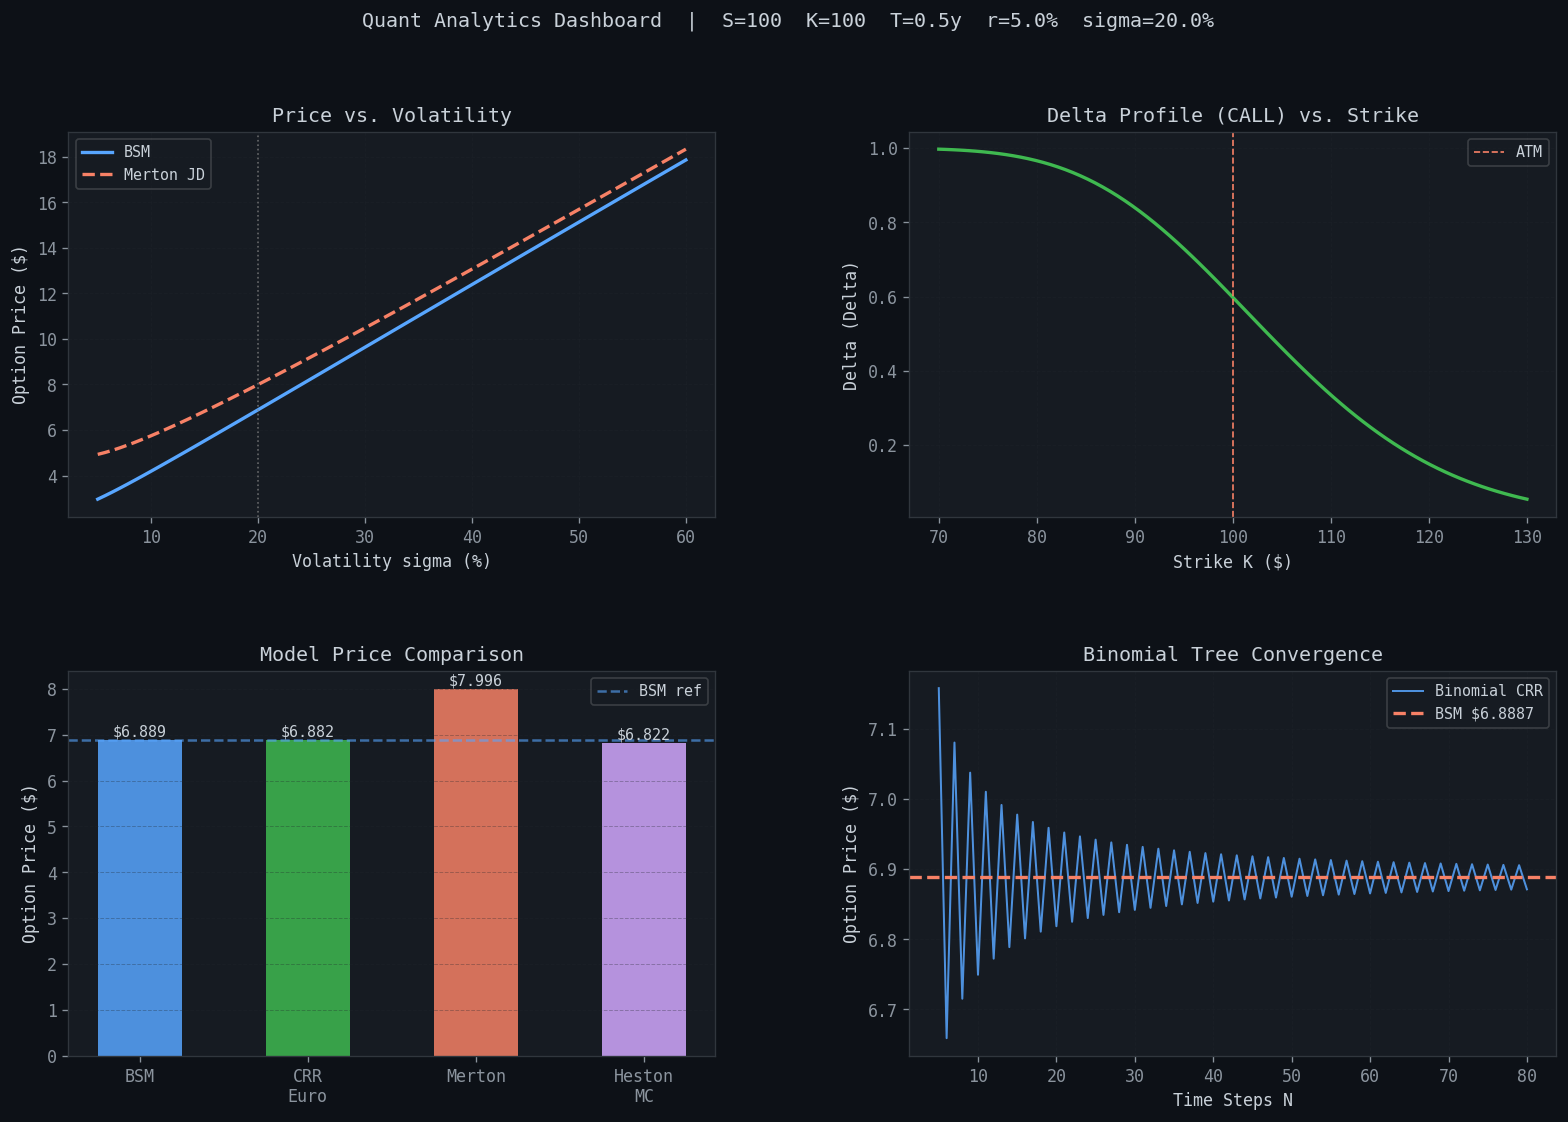


Generating Binomial convergence plot...


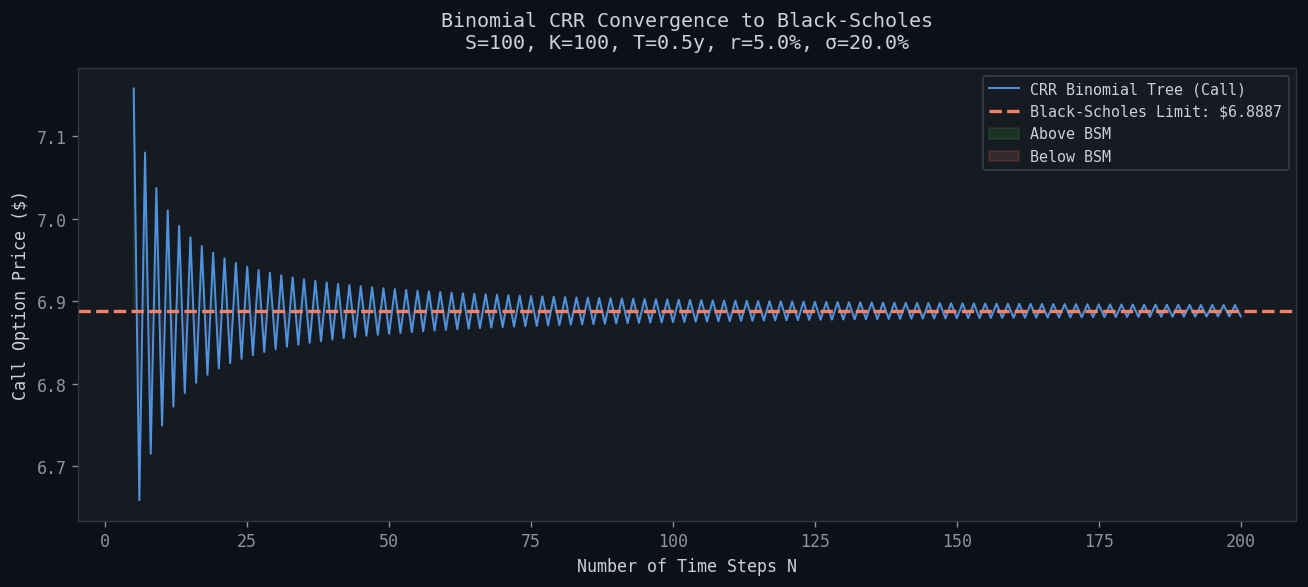

Generating Volatility Smile (synthetic fallback if no yfinance)...
[DEBUG] plot_volatility_smile called with: ticker=SPY, expiry_index=1, S=560, r=0.0525, debug_iv=False
[DEBUG] YFINANCE_AVAILABLE inside function: True
  -> Current date (pd.Timestamp.today()): 2026-06-03
  -> Calculated T_yrs: 0.0000
  -> Fetched 102 calls and 105 puts for expiry 2026-06-04.
  -> Processing 102 calls.
  -> 102 calls after filtering for bid >= 0.
  -> 100 calls after filtering for moneyness between 0.5 and 1.5.
  -> Raw IVs (call): [   nan 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.00

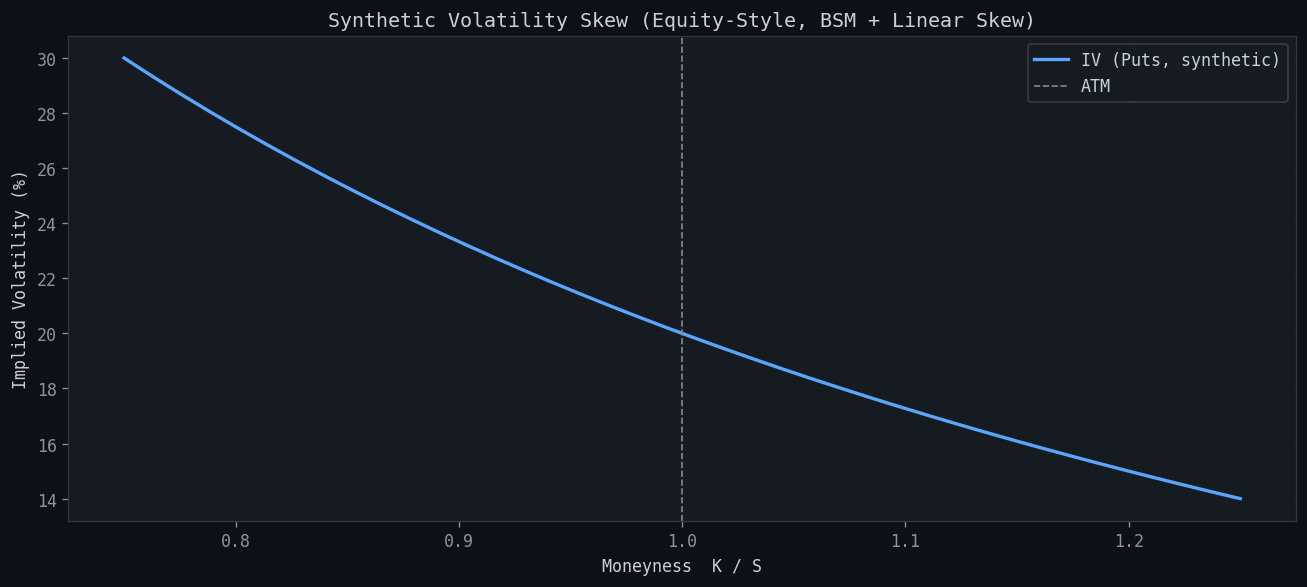

Generating Stochastic Path Visualiser (3 models x 10 paths)...


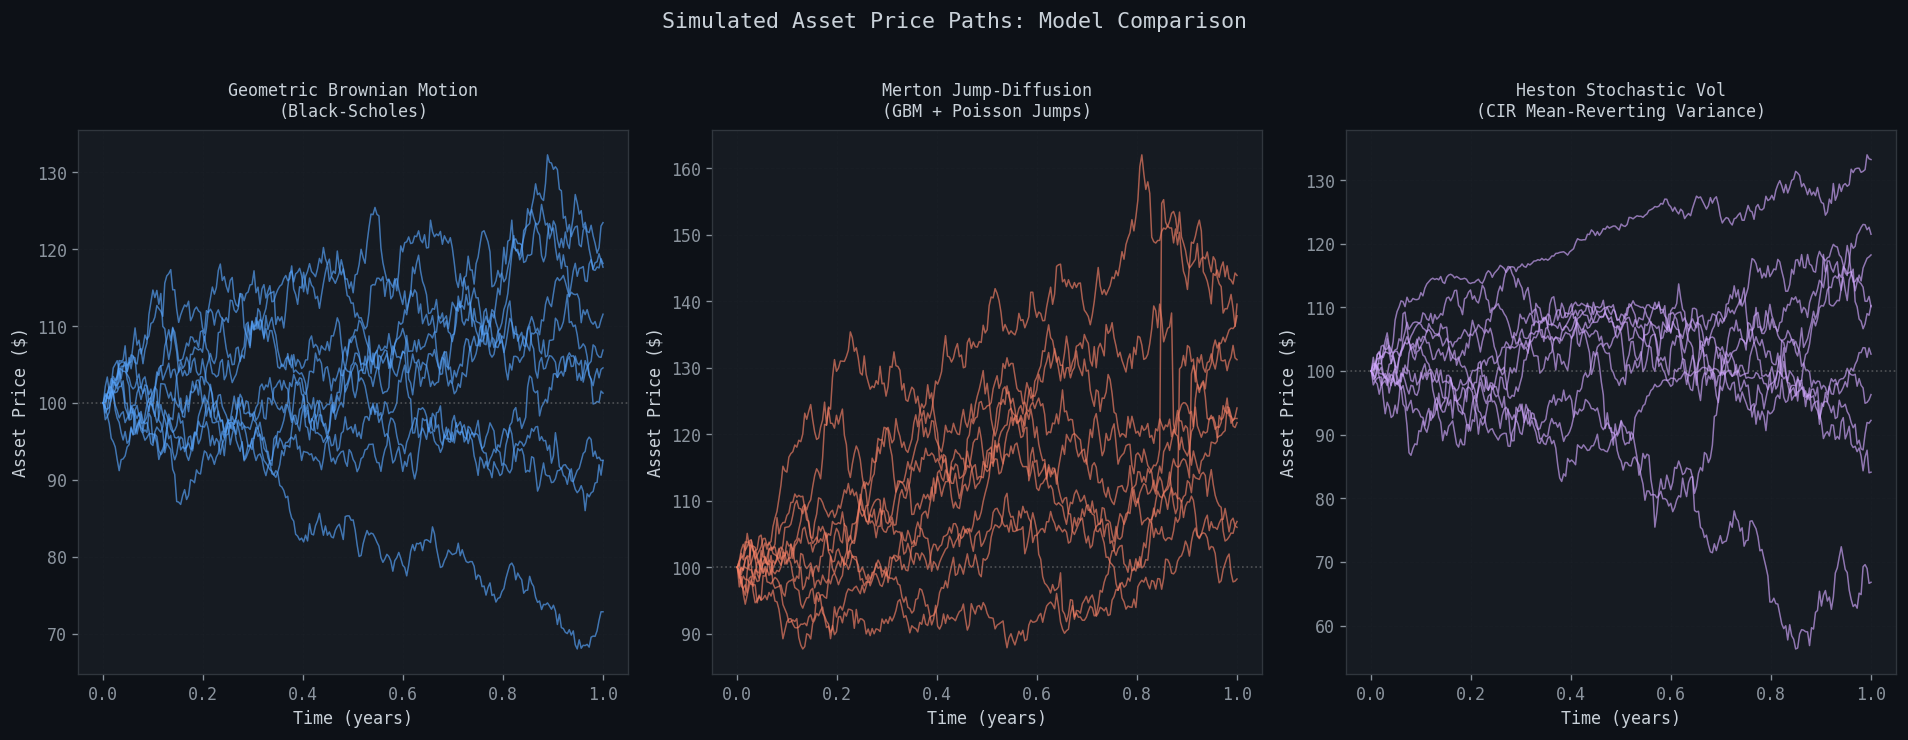


Launching interactive dashboard (requires ipywidgets)...


Dashboard rendered -- adjust sliders and press -> Run Analytics.

Suite execution complete.


In [51]:

# ─────────────────────────────────────────────────────────────
# CELL 7 · INTERACTIVE DASHBOARD & UNIT TEST VALIDATION
# ─────────────────────────────────────────────────────────────

# @title Quant Pricing Dashboard [Click to Run]

def run_suite_analytics(S=100, K=100, T=0.5, r=0.05, sigma=0.20,
                        # Heston parameters
                        kappa=2.0, theta=0.04, xi=0.3, rho=-0.70,
                        # Merton parameters
                        lam=0.5, mu_j=-0.10, sig_j=0.20,
                        option_type="call"):
    """
    Master analytics wrapper.  Computes:
    · Prices from all 4 engines (BSM, Binomial-CRR, Merton, Heston-MC)
    · Analytical Greeks (BSM) and numerical Greeks (Heston-MC)
    · Prints a formatted summary table
    · Produces a 2×2 comparison chart
    """

    print("\n" + "="*60)
    print("  QUANTITATIVE OPTION PRICING SUITE -- ANALYTICS REPORT")
    print("="*60)
    print(f"  Underlying : S = ${S:.2f}    Strike : K = ${K:.2f}")
    print(f"  Expiry     : T = {T:.4f}y   Rate   : r = {r*100:.2f}%")
    print(f"  Volatility : sigma = {sigma*100:.2f}%     Type   : {option_type.upper()}")
    print("-"*60)

    # -- 1. BSM ------------------------------------------------
    bsm      = BlackScholes(S, K, T, r, sigma)
    bsm_px   = bsm.call() if option_type == "call" else bsm.put()
    bsm_gr   = bsm.all_greeks(option_type)

    # -- 2. Binomial (N=200) -----------------------------------
    crr      = BinomialCRR(S, K, T, r, sigma, N=200, american=False)
    crr_px   = crr.call() if option_type == "call" else crr.put()
    crr_am   = BinomialCRR(S, K, T, r, sigma, N=200, american=True)
    crr_am_px = crr_am.call() if option_type == "call" else crr_am.put()

    # -- 3. Merton ---------------------------------------------
    merton   = MertonJumpDiffusion(S, K, T, r, sigma, lam, mu_j, sig_j)
    merton_px = merton.call() if option_type == "call" else merton.put()

    # -- 4. Heston MC ------------------------------------------
    v0 = sigma**2   # consistent initial variance
    heston    = HestonMonteCarlo(S, K, T, r, v0=v0,
                                  kappa=kappa, theta=theta,
                                  xi=xi, rho=rho,
                                  n_paths=20_000, n_steps=252)
    heston_px = heston.call() if option_type == "call" else heston.put()

    # -- Numerical Greeks (Heston) -----------------------------
    def heston_pricer(s, k, t, r_, sig):
        h = HestonMonteCarlo(s, k, t, r_, v0=sig**2,
                              kappa=kappa, theta=theta,
                              xi=xi, rho=rho,
                              n_paths=5_000, n_steps=63, seed=0)
        return h.call() if option_type == "call" else h.put()

    num_gr = numerical_greeks(heston_pricer, S, K, T, r, sigma)

    # -- Print price table -------------------------------------
    models  = ["Black-Scholes-Merton", "Binomial CRR (N=200, Euro)",
               "Binomial CRR (N=200, Amer)", "Merton Jump-Diffusion",
               "Heston Stochastic Vol (MC)"]
    prices  = [bsm_px, crr_px, crr_am_px, merton_px, heston_px]

    print(f"\n  {'MODEL':<32} {'PRICE':>10}  {'vs BSM':>10}")
    print(f"  {'-'*32} {'-'*10}  {'-'*10}")
    for m, p in zip(models, prices):
        diff = p - bsm_px
        print(f"  {m:<32} ${p:>9.4f}  {diff:>+10.4f}")

    # -- Print Greeks table ------------------------------------
    print(f"\n  {'GREEK':<12} {'BSM (Analytic)':>18} {'Heston (Numeric)':>18}")
    print(f"  {'-'*12} {'-'*18} {'-'*18}")
    for g in ["Delta", "Gamma", "Vega", "Theta"]:
        bv = bsm_gr.get(g, np.nan)
        nv = num_gr.get(g, np.nan)
        print(f"  {g:<12} {bv:>18.6f} {nv:>18.6f}")

    print("\n" + "="*60)

    # -- Visualisation -----------------------------------------
    _plot_analytics_summary(S, K, T, r, sigma,
                             option_type, bsm_px, merton_px, heston_px,
                             crr_px, bsm_gr, lam, mu_j, sig_j,
                             kappa, theta, xi, rho)

    return {
        "BSM": bsm_px, "CRR_Euro": crr_px, "CRR_Amer": crr_am_px,
        "Merton": merton_px, "Heston": heston_px,
        "BSM_Greeks": bsm_gr, "Heston_Greeks_Numeric": num_gr,
    }


def _plot_analytics_summary(S, K, T, r, sigma,
                              option_type, bsm_px, merton_px, heston_px,
                              crr_px, bsm_gr, lam, mu_j, sig_j,
                              kappa, theta, xi, rho):
    """Four-panel chart: vol surface slice, Greek profile, price comparison bar,
    and convergence inset."""

    sigma_range = np.linspace(0.05, 0.60, 80)
    K_range     = np.linspace(S * 0.70, S * 1.30, 80)

    # Panel 1: Price vs Vol
    bsm_vs_sig    = [BlackScholes(S, K, T, r, s).call() if option_type == "call"
                     else BlackScholes(S, K, T, r, s).put()
                     for s in sigma_range]
    merton_vs_sig = [MertonJumpDiffusion(S, K, T, r, s, lam, mu_j, sig_j).call()
                     if option_type == "call"
                     else MertonJumpDiffusion(S, K, T, r, s, lam, mu_j, sig_j).put()
                     for s in sigma_range]

    # Panel 2: Delta profile across strikes
    bsm_delta_k   = [BlackScholes(S, k, T, r, sigma).delta(option_type) for k in K_range]

    # Panel 3: Model price comparison bar
    labels  = ["BSM", "CRR\nEuro", "Merton", "Heston\nMC"]
    prices  = [bsm_px, crr_px, merton_px, heston_px]
    bar_col = [ACCENT, ACCENT3, ACCENT2, ACCENT4]

    # Panel 4: Binomial convergence (N=5..80 for speed)
    N_small = np.arange(5, 81)
    bin_conv = [BinomialCRR(S, K, T, r, sigma, N=n).call()
                if option_type == "call"
                else BinomialCRR(S, K, T, r, sigma, N=n).put()
                for n in N_small]

    # -- Build figure ------------------------------------------
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.30)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(sigma_range * 100, bsm_vs_sig,   color=ACCENT,  lw=2, label="BSM")
    ax1.plot(sigma_range * 100, merton_vs_sig, color=ACCENT2, lw=2, ls="--", label="Merton JD")
    ax1.axvline(sigma * 100, color="#888", lw=1, ls=":", alpha=0.7)
    ax1.set_xlabel("Volatility sigma (%)"); ax1.set_ylabel("Option Price ($)")
    ax1.set_title("Price vs. Volatility")
    ax1.legend(framealpha=0.2, fontsize=9); ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(K_range, bsm_delta_k, color=ACCENT3, lw=2)
    ax2.axvline(S, color=ACCENT2, lw=1, ls="--", label="ATM")
    ax2.set_xlabel("Strike K ($)"); ax2.set_ylabel("Delta (Delta)")
    ax2.set_title(f"Delta Profile ({option_type.upper()}) vs. Strike")
    ax2.legend(framealpha=0.2, fontsize=9); ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 0])
    bars = ax3.bar(labels, prices, color=bar_col, width=0.5, alpha=0.85)
    ax3.axhline(bsm_px, color=ACCENT, lw=1.5, ls="--", alpha=0.6, label="BSM ref")
    for bar, p in zip(bars, prices):
        ax3.text(bar.get_x() + bar.get_width()/2, p + 0.01,
                 f"${p:.3f}", ha="center", va="bottom", fontsize=9, color="#c9d1d9")
    ax3.set_ylabel("Option Price ($)")
    ax3.set_title("Model Price Comparison")
    ax3.legend(framealpha=0.2, fontsize=9); ax3.grid(True, alpha=0.3, axis="y")

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(N_small, bin_conv, color=ACCENT, lw=1.2, alpha=0.85, label="Binomial CRR")
    ax4.axhline(bsm_px, color=ACCENT2, lw=2, ls="--", label=f"BSM ${bsm_px:.4f}")
    ax4.set_xlabel("Time Steps N"); ax4.set_ylabel("Option Price ($)")
    ax4.set_title("Binomial Tree Convergence")
    ax4.legend(framealpha=0.2, fontsize=9); ax4.grid(True, alpha=0.3)

    fig.suptitle(f"Quant Analytics Dashboard  |  "
                 f"S={S}  K={K}  T={T}y  r={r*100:.1f}%  sigma={sigma*100:.1f}%",
                 fontsize=12, y=0.98)
    plt.show()


# ─────────────────────────────────────────────────────────────
# INTERACTIVE WIDGETS (ipywidgets, Colab-ready)
# ─────────────────────────────────────────────────────────────

def build_dashboard():
    """
    Construct and display the interactive ipywidgets control panel.
    If ipywidgets is not available (non-Colab environment) falls back
    to running with default parameter values.
    """
    if not WIDGETS_AVAILABLE:
        print("ipywidgets not available -- running suite with default parameters.")
        run_suite_analytics()
        return

    style  = {"description_width": "160px"}
    layout = widgets.Layout(width="420px")

    # -- Core parameters ---------------------------------------
    w_S     = widgets.FloatSlider(value=100, min=20, max=500,
                                   step=1, description="Spot Price S ($)", **{"style": style, "layout": layout})
    w_K     = widgets.FloatSlider(value=100, min=20, max=500,
                                   step=1, description="Strike K ($)", **{"style": style, "layout": layout})
    w_T     = widgets.FloatSlider(value=0.5, min=0.02, max=3.0,
                                   step=0.02, description="Expiry T (years)", **{"style": style, "layout": layout})
    w_sig   = widgets.FloatSlider(value=0.20, min=0.01, max=1.0,
                                   step=0.01, description="Volatility sigma", **{"style": style, "layout": layout})
    w_r     = widgets.FloatSlider(value=0.05, min=0.0, max=0.20,
                                   step=0.005, description="Risk-Free Rate r", **{"style": style, "layout": layout})
    w_type  = widgets.ToggleButtons(options=["call", "put"],
                                     description="Option Type",
                                     style={"description_width": "160px",
                                             "button_width": "80px"})

    # -- Merton parameters -------------------------------------
    w_lam   = widgets.FloatSlider(value=0.50, min=0.0,  max=5.0,
                                   step=0.05, description="Jump Intensity lambda", **{"style": style, "layout": layout})
    w_muj   = widgets.FloatSlider(value=-0.10, min=-0.5, max=0.5,
                                   step=0.01, description="Jump Mean mu_j", **{"style": style, "layout": layout})
    w_sigj  = widgets.FloatSlider(value=0.20, min=0.01, max=0.60,
                                   step=0.01, description="Jump Std sigma_j", **{"style": style, "layout": layout})

    # -- Heston parameters -------------------------------------
    w_kap   = widgets.FloatSlider(value=2.0,  min=0.1,  max=10.0,
                                   step=0.1,  description="Mean-Rev kappa", **{"style": style, "layout": layout})
    w_tht   = widgets.FloatSlider(value=0.04, min=0.005, max=0.25,
                                   step=0.005, description="Long-Run theta (var)", **{"style": style, "layout": layout})
    w_xi    = widgets.FloatSlider(value=0.30, min=0.05, max=1.5,
                                   step=0.05, description="Vol-of-Vol xi", **{"style": style, "layout": layout})
    w_rho   = widgets.FloatSlider(value=-0.70, min=-0.99, max=0.99,
                                   step=0.01, description="Correlation rho", **{"style": style, "layout": layout})

    # -- Run button --------------------------------------------
    btn     = widgets.Button(description="-> Run Analytics",
                              button_style="primary",
                              layout=widgets.Layout(width="200px", height="36px"))
    out     = widgets.Output()

    def on_run(_):
        with out:
            clear_output(wait=True)
            run_suite_analytics(
                S=w_S.value, K=w_K.value, T=w_T.value,
                r=w_r.value, sigma=w_sig.value,
                kappa=w_kap.value, theta=w_tht.value,
                xi=w_xi.value, rho=w_rho.value,
                lam=w_lam.value, mu_j=w_muj.value, sig_j=w_sigj.value,
                option_type=w_type.value,
            )

    btn.on_click(on_run)

    # -- Layout ------------------------------------------------
    core_box   = widgets.VBox([w_S, w_K, w_T, w_sig, w_r, w_type])
    merton_box = widgets.VBox([w_lam, w_muj, w_sigj])
    heston_box = widgets.VBox([w_kap, w_tht, w_xi, w_rho])

    acc = widgets.Accordion(children=[core_box, merton_box, heston_box])
    acc.set_title(0, " Core Parameters")
    acc.set_title(1, " Merton Jump-Diffusion")
    acc.set_title(2, " Heston Stochastic Volatility")

    header = widgets.HTML(
        "<h3 style='color:#58a6ff; font-family:monospace; margin:8px 0'>"
        " Quantitative Option Pricing & Volatility Analytics Suite</h3>"
        "<p style='color:#8b949e; font-family:monospace; font-size:12px'>"
        "Configure parameters below, then click Run Analytics.</p>")

    display(widgets.VBox([header, acc, btn, out]))
    print("Dashboard rendered -- adjust sliders and press -> Run Analytics.")


# ─────────────────────────────────────────────────────────────
# CELL 7B · AUTOMATED UNIT TEST & VALIDATION BLOCK
# ─────────────────────────────────────────────────────────────

def run_unit_tests(verbose=True):
    """
    Automated test suite validating core mathematical identities.

    Tests
    -----
    1. Put-Call Parity (BSM)
       C - P = S*e^{-qT} - K*e^{-rT}
       Should hold to machine precision for analytical BSM.

    2. Binomial -> BSM Convergence
       |CRR(N=500) - BSM| < 0.05$  (within 5 cents for large N)

    3. Merton Collapse to BSM (lambda->0)
       When jump intensity lambda->0, Merton reduces to BSM.
       |Merton(lambda=1e-9) - BSM| < 0.01$

    4. Heston Collapse to BSM (xi->0, v0=theta=sigma^2)
       When vol-of-vol xi->0 and v0=theta=sigma^2, variance is constant = sigma^2.
       |Heston(xi=0.001) - BSM| < 0.10$  (MC noise tolerance)

    5. BSM Delta Bounds
       0 <= Delta_call <= 1,  -1 <= Delta_put <= 0

    6. Gamma Positivity
       Gamma > 0 for both calls and puts

    7. Vega Positivity
       V > 0 (longer vol = more expensive options)

    8. American >= European Premium
       American put >= European put (early exercise has positive value for puts)
    """
    PASS = "  PASS"
    FAIL = "  FAIL"
    tol  = 0.10
    results = []

    S, K, T, r, sigma = 100.0, 100.0, 0.5, 0.05, 0.20

    bsm = BlackScholes(S, K, T, r, sigma)
    C   = bsm.call()
    P   = bsm.put()

    # -- Test 1: Put-Call Parity -------------------------------
    lhs = C - P
    rhs = S - K * np.exp(-r * T)
    err1 = abs(lhs - rhs)
    ok1 = err1 < 1e-10
    results.append(("Put-Call Parity (BSM)", ok1,
                    f"C-P={lhs:.8f}, S-Ke^(-rT)={rhs:.8f}, err={err1:.2e}"))

    # -- Test 2: Binomial Convergence --------------------------
    crr_px  = BinomialCRR(S, K, T, r, sigma, N=500).call()
    err2    = abs(crr_px - C)
    ok2     = err2 < 0.05
    results.append(("Binomial N=500 -> BSM", ok2,
                    f"CRR={crr_px:.5f}, BSM={C:.5f}, Delta=${err2:.5f}"))

    # -- Test 3: Merton Collapse (lambda->0) -------------------
    merton_eps = MertonJumpDiffusion(S, K, T, r, sigma,
                                      lam=1e-9, mu_j=0, sig_j=0.01).call()
    err3 = abs(merton_eps - C)
    ok3  = err3 < 0.01
    results.append(("Merton(lambda->0) -> BSM", ok3,
                    f"Merton={merton_eps:.5f}, BSM={C:.5f}, Delta=${err3:.5f}"))

    # -- Test 4: Heston Collapse (xi->0, v0=theta=sigma^2) -------------
    heston_eps = HestonMonteCarlo(S, K, T, r,
                                   v0=sigma**2, kappa=5.0,
                                   theta=sigma**2, xi=0.001,
                                   rho=0.0,
                                   n_paths=30_000, n_steps=252, seed=42).call()
    err4 = abs(heston_eps - C)
    ok4  = err4 < 0.10
    results.append(("Heston(xi->0) -> BSM", ok4,
                    f"Heston={heston_eps:.5f}, BSM={C:.5f}, Delta=${err4:.5f}"))

    # -- Test 5: Delta Bounds ----------------------------------
    d_call = bsm.delta("call")
    d_put  = bsm.delta("put")
    ok5    = (0 <= d_call <= 1) and (-1 <= d_put <= 0)
    results.append(("Delta Bounds", ok5,
                    f"Delta_call={d_call:.5f}, Delta_put={d_put:.5f}"))

    # -- Test 6: Gamma Positivity ------------------------------
    gamma = bsm.gamma()
    ok6   = gamma > 0
    results.append(("Gamma > 0", ok6, f"Gamma={gamma:.6f}"))

    # -- Test 7: Vega Positivity -------------------------------
    vega = bsm.vega()
    ok7  = vega > 0
    results.append(("Vega > 0", ok7, f"V={vega:.6f}"))

    # -- Test 8: American >= European Put ----------------------
    euro_put = BinomialCRR(S, K, T, r, sigma, N=200, american=False).put()
    amer_put = BinomialCRR(S, K, T, r, sigma, N=200, american=True).put()
    ok8      = amer_put >= euro_put - 1e-6
    results.append(("American Put >= European Put", ok8,
                    f"Euro={euro_put:.5f}, Amer={amer_put:.5f}, diff={amer_put-euro_put:.5f}"))

    # -- Print results -----------------------------------------
    print("\n" + "="*60)
    print("  AUTOMATED UNIT TEST RESULTS")
    print("="*60)
    all_pass = True
    for name, ok, detail in results:
        status = PASS if ok else FAIL
        all_pass = all_pass and ok
        if verbose:
            print(f"{status}  {name}")
            print(f"         {detail}")
    print("-"*60)
    if all_pass:
        print("  ALL TESTS PASSED")
    else:
        n_fail = sum(1 for _, ok, _ in results if not ok)
        print(f"  WARNING: {n_fail} TEST(S) FAILED - review output above")
    print("="*60 + "\n")

    return all_pass


# ─────────────────────────────────────────────────────────────
# MAIN EXECUTION ENTRY POINT
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("\n" + "#"*60)
    print("  QUANTITATIVE OPTION PRICING & VOLATILITY ANALYTICS SUITE")
    print("  Mathematical progression: BSM -> CRR -> Merton -> Heston")
    print("#"*60 + "\n")

    # -- 1. Unit tests first (fast validation) -----------------
    run_unit_tests(verbose=True)

    # -- 2. Core pricing demo -----------------------------------
    print("Running suite analytics with default parameters...")
    results = run_suite_analytics(
        S=100, K=100, T=0.5, r=0.05, sigma=0.20,
        kappa=2.0, theta=0.04, xi=0.3, rho=-0.70,
        lam=0.5, mu_j=-0.10, sig_j=0.20,
        option_type="call",
    )

    # -- 3. Research plots --------------------------------------
    print("\nGenerating Binomial convergence plot...")
    plot_binomial_convergence(S=100, K=100, T=0.5, r=0.05, sigma=0.20)

    print("Generating Volatility Smile (synthetic fallback if no yfinance)...")
    plot_volatility_smile(ticker="SPY", S=560, r=0.0525)

    print("Generating Stochastic Path Visualiser (3 models x 10 paths)...")
    plot_stochastic_paths(S0=100, r=0.05, sigma=0.20, T=1.0)

    # -- 4. Interactive dashboard (Colab / Jupyter only) --------
    print("\nLaunching interactive dashboard (requires ipywidgets)...")
    build_dashboard()

    print("\nSuite execution complete.")


## CELL 7: Interactive Dashboard & Unit Test Validation

This final section provides both an interactive interface for exploring the pricing models and a robust suite of unit tests to ensure their mathematical integrity.

### Quant Pricing Dashboard (`build_dashboard`)

This interactive dashboard, built using `ipywidgets` (if available), allows users to adjust various model parameters (spot price, strike, expiry, volatility, jump-diffusion, Heston parameters) and instantly see the impact on option prices and Greeks across all implemented models. It provides a dynamic way to explore the relationships between model inputs and outputs.

### Automated Unit Test & Validation Block (`run_unit_tests`)

This block contains a series of automated unit tests to validate the correctness of the option pricing models and Greek calculations. It checks for fundamental financial identities like Put-Call Parity, convergence of the binomial model to BSM, and expected behavior of Merton and Heston models under specific conditions. It serves as a critical quality assurance step for the financial engineering suite.


--- Retrying Volatility Smile Plot with error logging ---
[DEBUG] plot_volatility_smile called with: ticker=SPY, expiry_index=1, S=560, r=0.0525, debug_iv=False
[DEBUG] YFINANCE_AVAILABLE inside function: True
  -> Current date (pd.Timestamp.today()): 2026-06-03
  -> Calculated T_yrs: 0.0000
  -> Fetched 102 calls and 105 puts for expiry 2026-06-04.
  -> Processing 102 calls.
  -> 102 calls after filtering for bid >= 0.
  -> 100 calls after filtering for moneyness between 0.5 and 1.5.
  -> Raw IVs (call): [   nan 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001
 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.000

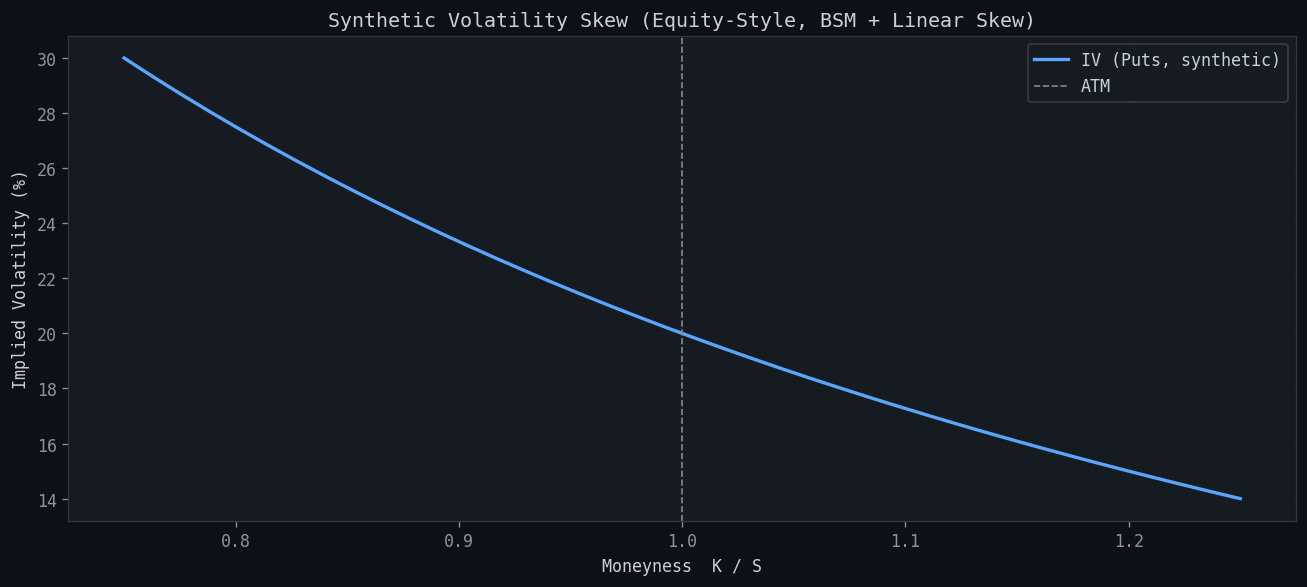

In [49]:
print("\n--- Retrying Volatility Smile Plot with error logging ---")
try:
    plot_volatility_smile(ticker="SPY", S=560, r=0.0525)
except Exception as e:
    import traceback
    print(f"An error occurred during plot_volatility_smile: {e}")
    traceback.print_exc()

Running suite analytics with default parameters…

════════════════════════════════════════════════════════════
  QUANTITATIVE OPTION PRICING SUITE — ANALYTICS REPORT
════════════════════════════════════════════════════════════
  Underlying : S = $100.00    Strike : K = $100.00
  Expiry     : T = 0.5000y   Rate   : r = 5.00%
  Volatility : σ = 20.00%     Type   : CALL
────────────────────────────────────────────────────────────

  MODEL                                 PRICE      vs BSM
  ──────────────────────────────── ──────────  ──────────
  Black-Scholes-Merton             $   6.8887     +0.0000
  Binomial CRR (N=200, Euro)       $   6.8817     -0.0071
  Binomial CRR (N=200, Amer)       $   6.8817     -0.0071
  Merton Jump-Diffusion            $   7.9959     +1.1071
  Heston Stochastic Vol (MC)       $   6.8218     -0.0669

  GREEK            BSM (Analytic)   Heston (Numeric)
  ──────────── ────────────────── ──────────────────
  Delta                  0.597734           0.656091
  

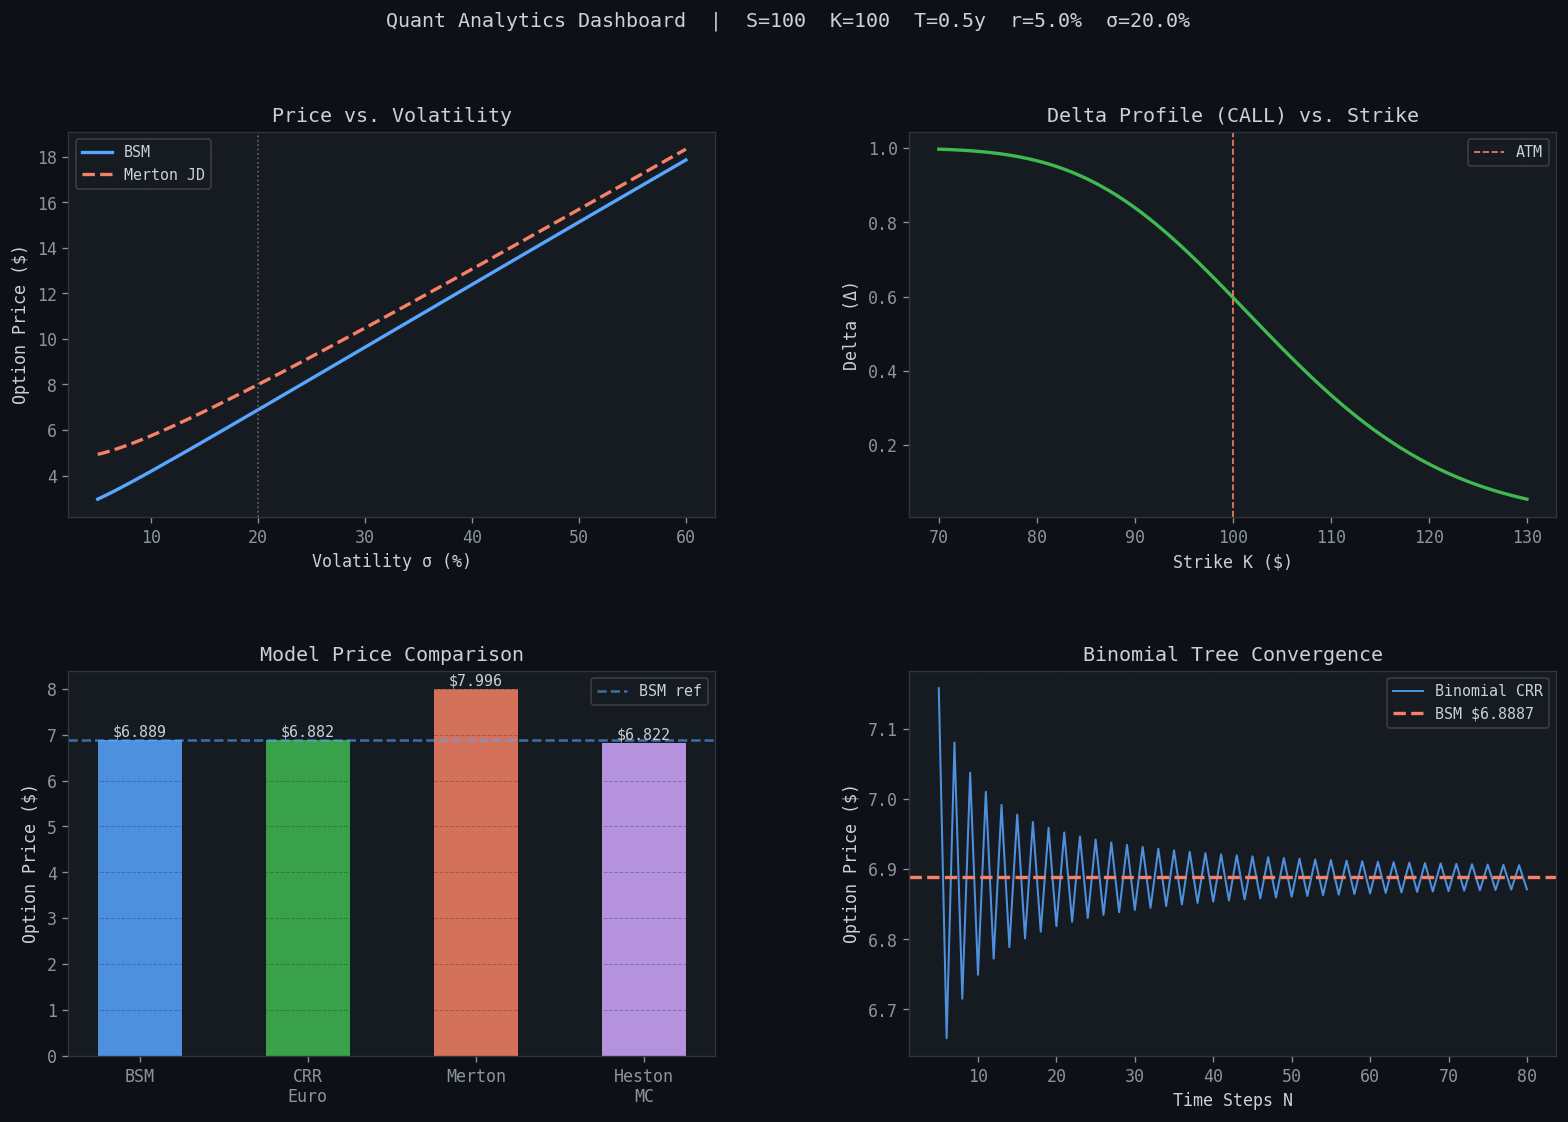


Generating Binomial convergence plot…


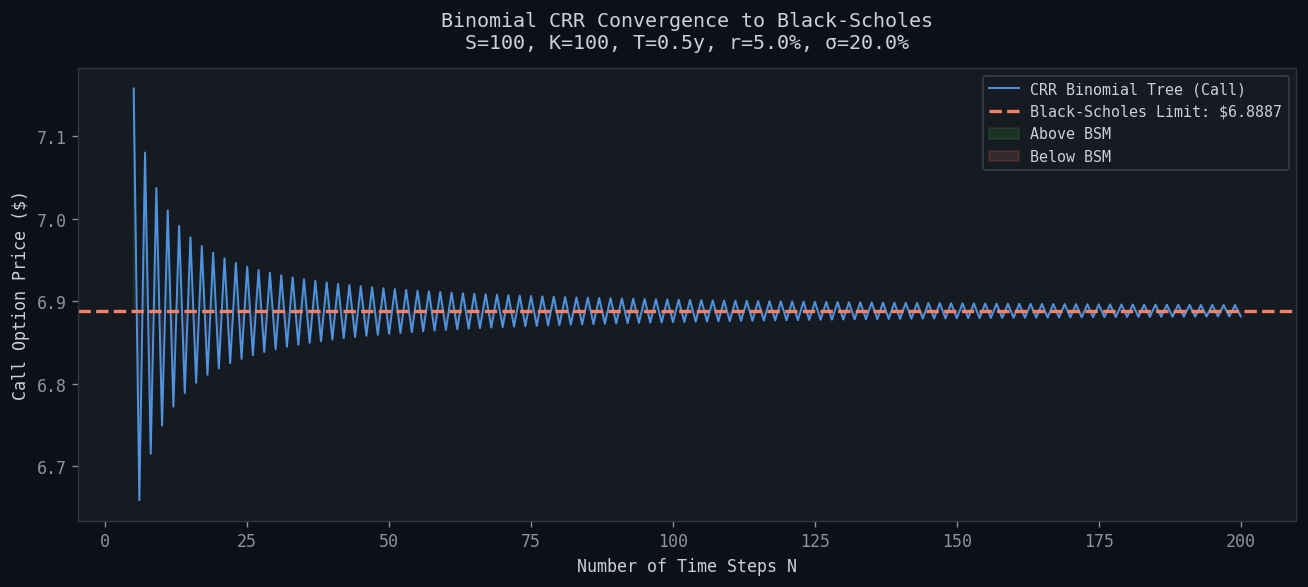

Generating Volatility Smile (synthetic fallback if no yfinance)…
[DEBUG] plot_volatility_smile called with: ticker=MSFT, expiry_index=20, S=560, r=0.0525, debug_iv=True
[DEBUG] YFINANCE_AVAILABLE inside function: True
  -> Current date (pd.Timestamp.today()): 2026-06-03
  -> Calculated T_yrs: 1.6329
  -> Fetched 93 calls and 90 puts for expiry 2028-01-21.
  -> Processing 93 calls.
  -> 93 calls after filtering for bid >= 0.
  -> 79 calls after filtering for moneyness between 0.5 and 1.5.
    [IV Debug] S=560.00, K=290.00, T=1.6329, r=0.0362, Price=0.0000, Intrinsic=286.6362
    [IV Debug] Market price (0.0000) below intrinsic (286.6362). Returning NaN.
    [IV Debug] S=560.00, K=300.00, T=1.6329, r=0.0362, Price=0.0000, Intrinsic=277.2099
    [IV Debug] Market price (0.0000) below intrinsic (277.2099). Returning NaN.
    [IV Debug] S=560.00, K=310.00, T=1.6329, r=0.0362, Price=0.0000, Intrinsic=267.7835
    [IV Debug] Market price (0.0000) below intrinsic (267.7835). Returning NaN.
   

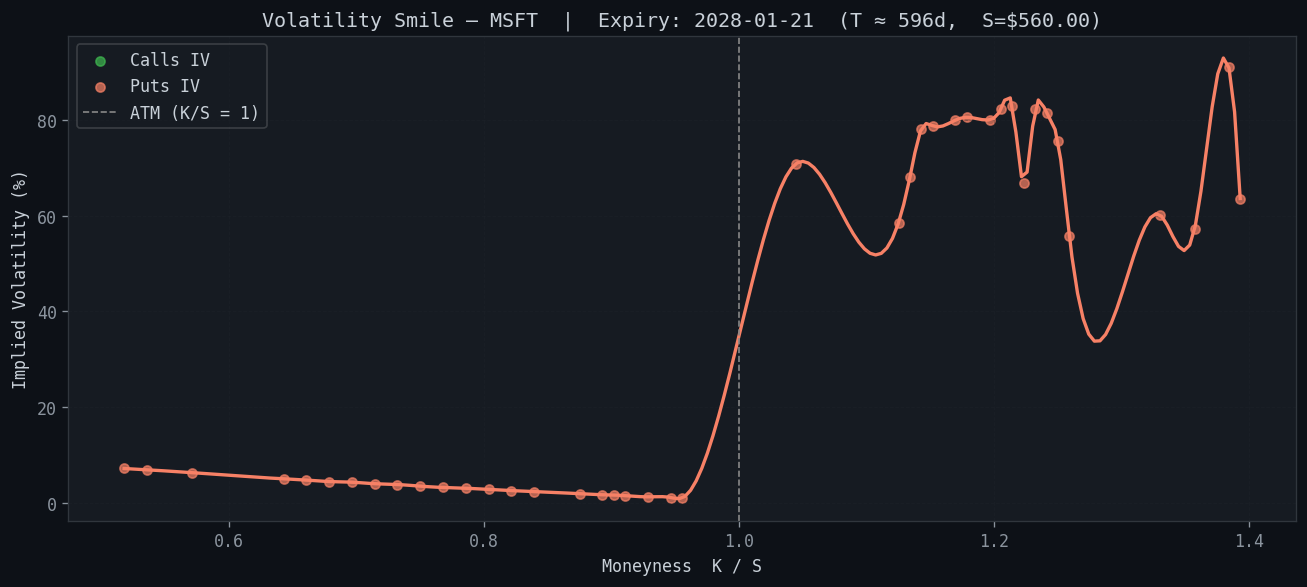

Generating Stochastic Path Visualiser (3 models × 10 paths)…


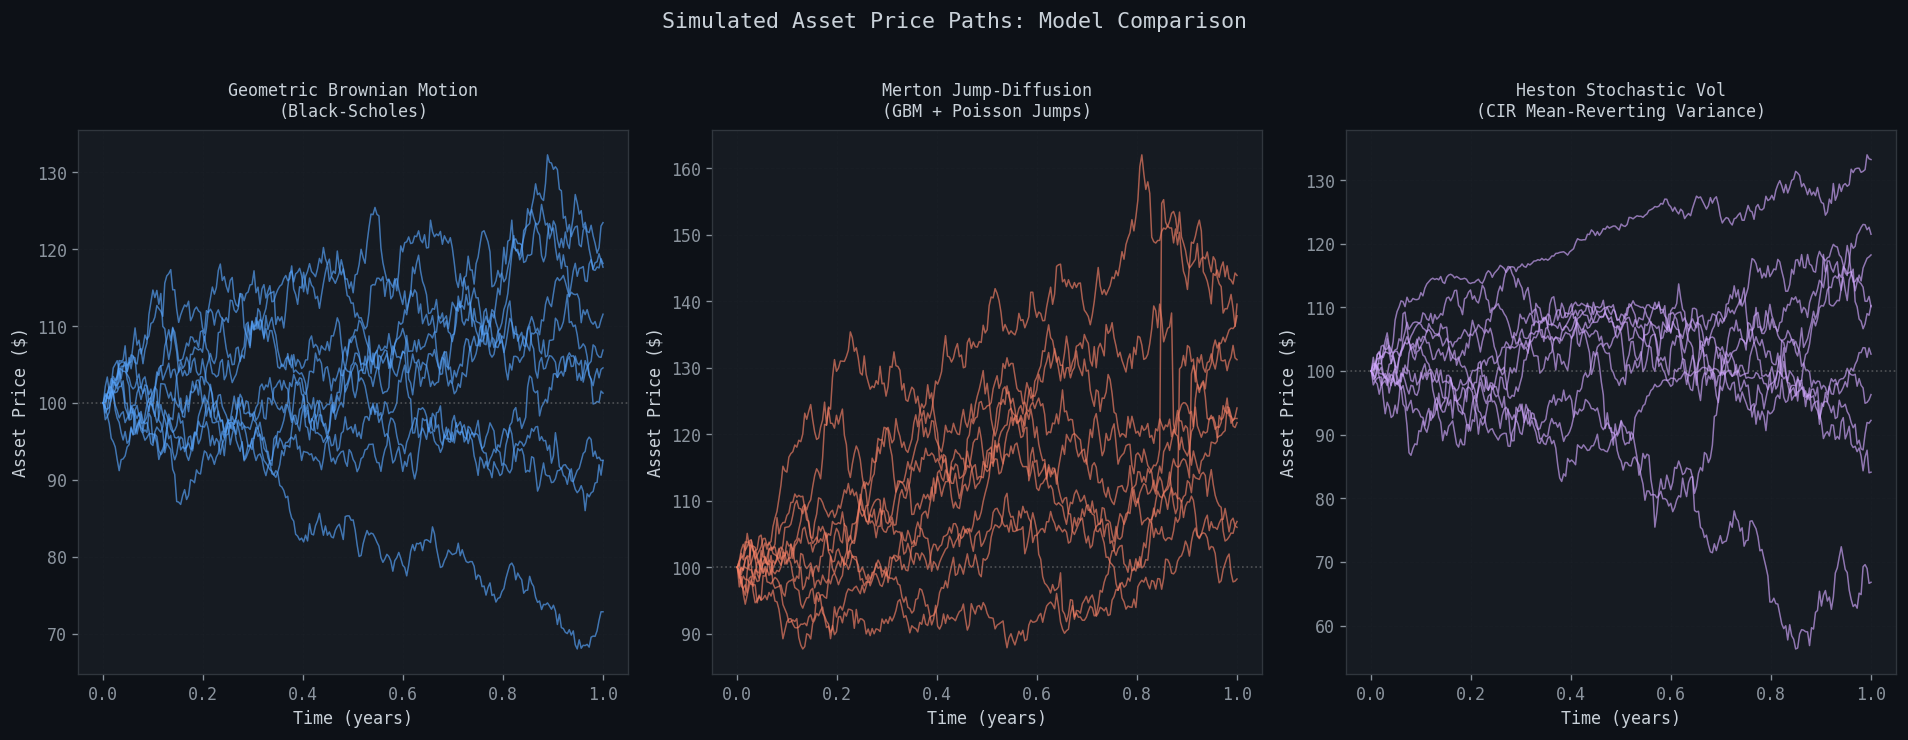

In [50]:
print("Running suite analytics with default parameters…")
results = run_suite_analytics(
    S=100, K=100, T=0.5, r=0.05, sigma=0.20,
    kappa=2.0, theta=0.04, xi=0.3, rho=-0.70,
    lam=0.5, mu_j=-0.10, sig_j=0.20,
    option_type="call",
)

print("\nGenerating Binomial convergence plot…")
plot_binomial_convergence(S=100, K=100, T=0.5, r=0.05, sigma=0.20)

print("Generating Volatility Smile (synthetic fallback if no yfinance)…")
plot_volatility_smile(ticker="MSFT", expiry_index=20, S=560, r=0.0525, debug_iv=True)

print("Generating Stochastic Path Visualiser (3 models × 10 paths)…")
plot_stochastic_paths(S0=100, r=0.05, sigma=0.20, T=1.0)

## Conclusion

This notebook serves as a comprehensive toolkit for quantitative option pricing and volatility analysis, covering models from the foundational Black-Scholes-Merton to advanced stochastic volatility and jump-diffusion frameworks. It includes functionalities for live market data integration, implied volatility extraction, numerical Greek computations, and interactive visualizations, all validated by a suite of unit tests. This allows for both theoretical exploration and practical application of derivatives analytics.